# Sample client usage of Quantization Service

#### sample to set up service server
see https://github.com/vuiseng9/nncf/blob/qaas-dec2021/qaas/host_qaas_image_classification.sh
    

In [1]:
import os, time, random, torch, sys, requests, json
import numpy as np, pandas as pd
from copy import deepcopy
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
host_url = 'http://csr-dgx1-03.jf.intel.com:5000/'

In [3]:
url_ready = host_url + 'ready_state'
url_graphviz = host_url + 'get_model_graph_viz'
url_optype = host_url + 'get_node2optype_map'
url_connectivity = host_url + 'get_connectivity_map'
url_quantizable = host_url + 'get_quantizable_attr'
url_graph_features = host_url + 'layer_graph_data'
url_eval_req = host_url + 'sample_eval_req'
url_evaluate = host_url + 'evaluate'
url_test = host_url + 'test'

#### Check if service is ready

In [4]:
requests.get(url=url_ready).json()

{'config': '/home/vchua/qaas_2112/nncf/qaas/cfg/resnet18_imgnet_qaas.json',
 'method': 'ready_state',
 'msg': 'Environment imgnet initialized',
 'rc': 0}

#### Graph visualization

Note: you can download through browser with this url http://csr-dgx1-03.jf.intel.com:5002/get_model_graph_viz


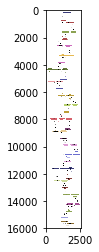

In [5]:
# download a copy of model graph with colorized grouped quantizer nodes
print('Note: you can download through browser with this url {}'.format(url_graphviz))

imgpth = 'model_graph.png'
r = requests.get(url_graphviz, allow_redirects=True)
with open(imgpth, 'wb') as fh:
    fh.write(r.content)

plt.imshow(plt.imread(imgpth))

### Graph node to operation type

In [6]:
node_type=requests.get(url=url_optype).json()
node_type

{'0 /nncf_model_input_0': 'nncf_model_input',
 '1 AsymmetricQuantizer/asymmetric_quantize_0': 'asymmetric_quantize',
 '10 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn1]/batch_norm_0': 'batch_norm',
 '100 ResNet/Sequential[layer4]/BasicBlock[0]/Sequential[downsample]/NNCFBatchNorm[1]/AsymmetricQuantizer/asymmetric_quantize_0': 'asymmetric_quantize',
 '101 ResNet/Sequential[layer4]/BasicBlock[0]/__iadd___0': '__iadd__',
 '102 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/relu__1': 'relu_',
 '103 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/AsymmetricQuantizer/asymmetric_quantize_1': 'asymmetric_quantize',
 '104 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0': 'asymmetric_quantize',
 '105 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/conv2d_0': 'conv2d',
 '106 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFBatchNorm[bn1]/batch_norm_0': 'batch_norm',
 '107 ResNet/Seq

### Connectivity of nodes

In [7]:
node_conn = requests.get(url=url_connectivity).json()
# key of the dictionary is source node
# value is a list of destination nodes

# nodetype can be looked up via previous mapping

for i, (src_node, dst_nodes) in enumerate(node_conn.items()):
    print("* ({}) {}".format(node_type[src_node], src_node))
    for dst_node in dst_nodes:
        print("\t-> ({}) {}".format(node_type[dst_node], dst_node))
    print("")
    if i>=5:
        break

* (nncf_model_input) 0 /nncf_model_input_0
	-> (asymmetric_quantize) 1 AsymmetricQuantizer/asymmetric_quantize_0

* (asymmetric_quantize) 1 AsymmetricQuantizer/asymmetric_quantize_0
	-> (conv2d) 3 ResNet/NNCFConv2d[conv1]/conv2d_0

* (batch_norm) 10 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn1]/batch_norm_0
	-> (relu_) 11 ResNet/Sequential[layer1]/BasicBlock[0]/ReLU[relu]/relu__0

* (asymmetric_quantize) 100 ResNet/Sequential[layer4]/BasicBlock[0]/Sequential[downsample]/NNCFBatchNorm[1]/AsymmetricQuantizer/asymmetric_quantize_0
	-> (__iadd__) 101 ResNet/Sequential[layer4]/BasicBlock[0]/__iadd___0

* (__iadd__) 101 ResNet/Sequential[layer4]/BasicBlock[0]/__iadd___0
	-> (relu_) 102 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/relu__1

* (relu_) 102 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/relu__1
	-> (asymmetric_quantize) 103 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/AsymmetricQuantizer/asymmetric_quantize_1



### Features of quantizable nodes

In [8]:
url_quantizable

'http://csr-dgx1-03.jf.intel.com:5002/get_quantizable_attr'

In [9]:
quantizable_attr = requests.get(url=url_quantizable).json()

In [10]:
quantizable_df = pd.DataFrame.from_dict(quantizable_attr)

In [11]:
quantizable_df.head()

,cin,conv_dw,cout,gid,ifm_size,is_wt_quantizer,kernel,node_name,param,stride
/nncf_model_input_0|OUTPUT,3.0,0.0,3.0,0,50176.0,False,0.0,0 /nncf_model_input_0,0.0,0.0
ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0|OUTPUT,512.0,0.0,512.0,13,1.0,False,0.0,116 ResNet/AdaptiveAvgPool2d[avgpool]/adaptive...,0.0,0.0
ResNet/NNCFConv2d[conv1]/conv2d_0|WEIGHT,3.0,0.0,64.0,0,50176.0,True,7.0,3 ResNet/NNCFConv2d[conv1]/conv2d_0,9408.0,2.0
ResNet/NNCFLinear[fc]/linear_0|WEIGHT,512.0,0.0,1000.0,13,512.0,True,1.0,120 ResNet/NNCFLinear[fc]/linear_0,512000.0,0.0
ResNet/ReLU[relu]/relu__0|OUTPUT,64.0,0.0,64.0,14,12544.0,False,0.0,5 ResNet/ReLU[relu]/relu__0,0.0,0.0


Nodes grouped as a cluster can be found in this table by ```gid```. ```node_name``` can be used to looked up optype and connectivity map.

In [12]:
node2gid = quantizable_df[['node_name', 'gid']].set_index('node_name').to_dict()

In [13]:
node2gid['gid']

{'0 /nncf_model_input_0': 0,
 '116 ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0': 13,
 '3 ResNet/NNCFConv2d[conv1]/conv2d_0': 0,
 '120 ResNet/NNCFLinear[fc]/linear_0': 13,
 '5 ResNet/ReLU[relu]/relu__0': 14,
 '15 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn2]/batch_norm_0': 14,
 '9 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFConv2d[conv1]/conv2d_0': 14,
 '14 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFConv2d[conv2]/conv2d_0': 1,
 '11 ResNet/Sequential[layer1]/BasicBlock[0]/ReLU[relu]/relu__0': 1,
 '18 ResNet/Sequential[layer1]/BasicBlock[0]/ReLU[relu]/relu__1': 15,
 '27 ResNet/Sequential[layer1]/BasicBlock[1]/NNCFBatchNorm[bn2]/batch_norm_0': 15,
 '21 ResNet/Sequential[layer1]/BasicBlock[1]/NNCFConv2d[conv1]/conv2d_0': 15,
 '26 ResNet/Sequential[layer1]/BasicBlock[1]/NNCFConv2d[conv2]/conv2d_0': 2,
 '23 ResNet/Sequential[layer1]/BasicBlock[1]/ReLU[relu]/relu__0': 2,
 '30 ResNet/Sequential[layer1]/BasicBlock[1]/ReLU[relu]/relu__1': 16,
 '39 ResNet/Sequential[layer

#### Features per Node API

In [14]:
graph_features = requests.get(url=url_graph_features).json()

In [15]:
graph_feature_df = pd.DataFrame.from_dict(graph_features)

In [16]:
graph_features.keys()

dict_keys(['action_space', 'edges', 'node_features', 'rc'])

In [17]:
graph_features['action_space']

{'discrete': [2, 3, 4, 5, 6, 7, 8]}

#### Sample evaluation configuration

In [18]:
eval_cfg = requests.get(url=url_eval_req).json()
# key is quantization group id
# value is the bitwidth of a node
eval_cfg

{'bool_bnadap': True,
 'bw_cfg': {'0 /nncf_model_input_0': 6,
  '1 AsymmetricQuantizer/asymmetric_quantize_0': 0,
  '10 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn1]/batch_norm_0': 0,
  '100 ResNet/Sequential[layer4]/BasicBlock[0]/Sequential[downsample]/NNCFBatchNorm[1]/AsymmetricQuantizer/asymmetric_quantize_0': 0,
  '101 ResNet/Sequential[layer4]/BasicBlock[0]/__iadd___0': 0,
  '102 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/relu__1': 2,
  '103 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/AsymmetricQuantizer/asymmetric_quantize_1': 0,
  '104 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0': 0,
  '105 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/conv2d_0': 5,
  '106 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFBatchNorm[bn1]/batch_norm_0': 0,
  '107 ResNet/Sequential[layer4]/BasicBlock[1]/ReLU[relu]/relu__0': 4,
  '108 ResNet/Sequential[layer4]/BasicBlock[

#### Evaluation with random bitwidth (reuse sample request above)

In [19]:
# print eval_cfg to see more

In [20]:
req = requests.post(url_evaluate, json = eval_cfg)

In [21]:
eval_results = req.json()

In [22]:
eval_results['meta_data']['hostname']

'csr-dgx1-03'

In [23]:
eval_results['meta_data']

{'bop_ratio': 0.17689646841533657,
 'eval_type': 'evaluate',
 'executed_bw_cfg': {'/nncf_model_input_0|OUTPUT': 6,
  'ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0|OUTPUT': 8,
  'ResNet/NNCFConv2d[conv1]/conv2d_0|WEIGHT': 5,
  'ResNet/NNCFLinear[fc]/linear_0|WEIGHT': 2,
  'ResNet/ReLU[relu]/relu__0|OUTPUT': 6,
  'ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn2]/batch_norm_0|OUTPUT': 2,
  'ResNet/Sequential[layer1]/BasicBlock[0]/NNCFConv2d[conv1]/conv2d_0|WEIGHT': 5,
  'ResNet/Sequential[layer1]/BasicBlock[0]/NNCFConv2d[conv2]/conv2d_0|WEIGHT': 5,
  'ResNet/Sequential[layer1]/BasicBlock[0]/ReLU[relu]/relu__0|OUTPUT': 6,
  'ResNet/Sequential[layer1]/BasicBlock[0]/ReLU[relu]/relu__1|OUTPUT': 2,
  'ResNet/Sequential[layer1]/BasicBlock[1]/NNCFBatchNorm[bn2]/batch_norm_0|OUTPUT': 4,
  'ResNet/Sequential[layer1]/BasicBlock[1]/NNCFConv2d[conv1]/conv2d_0|WEIGHT': 6,
  'ResNet/Sequential[layer1]/BasicBlock[1]/NNCFConv2d[conv2]/conv2d_0|WEIGHT': 5,
  'ResNet/Sequential[layer1]

In [24]:
for k in eval_results.keys():
    print(k)

cached_eval
meta_data
msg
processing_time
rc


### Two type of evaluation (synonymous to ML validation and test)

In [25]:
# both /evaluate and /test have exact interface
host_url = 'http://csr-dgx1-03.jf.intel.com:5000/'
url_evaluate = host_url + 'evaluate'
url_test = host_url + 'test'
url_eval_req = host_url + 'sample_eval_req'

In [26]:
eval_cfg = requests.get(url=url_eval_req).json()
eval_cfg

{'bool_bnadap': True,
 'bw_cfg': {'0 /nncf_model_input_0': 6,
  '1 AsymmetricQuantizer/asymmetric_quantize_0': 0,
  '10 ResNet/Sequential[layer1]/BasicBlock[0]/NNCFBatchNorm[bn1]/batch_norm_0': 0,
  '100 ResNet/Sequential[layer4]/BasicBlock[0]/Sequential[downsample]/NNCFBatchNorm[1]/AsymmetricQuantizer/asymmetric_quantize_0': 0,
  '101 ResNet/Sequential[layer4]/BasicBlock[0]/__iadd___0': 0,
  '102 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/relu__1': 3,
  '103 ResNet/Sequential[layer4]/BasicBlock[0]/ReLU[relu]/AsymmetricQuantizer/asymmetric_quantize_1': 0,
  '104 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0': 0,
  '105 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFConv2d[conv1]/conv2d_0': 4,
  '106 ResNet/Sequential[layer4]/BasicBlock[1]/NNCFBatchNorm[bn1]/batch_norm_0': 0,
  '107 ResNet/Sequential[layer4]/BasicBlock[1]/ReLU[relu]/relu__0': 4,
  '108 ResNet/Sequential[layer4]/BasicBlock[

In [27]:
# print(json.dumps(eval_cfg, indent=4))

##### note that a metadata (key:eval_type) to indicate the type of evaluation

In [28]:
# evaluate
eval_cfg['bool_bnadap']=False
req = requests.post(url_evaluate, json = eval_cfg)
eval_results = req.json()
print("Eval type: {}, BN_Adap: {}".format(eval_results['meta_data']['eval_type'], eval_results['meta_data']['executed_wt_bnadap']))
print("task_metric", eval_results['meta_data']['task_metric'])
print("bop_ratio: {:5}, size_ratio: {:5}".format(eval_results['meta_data']['bop_ratio'], eval_results['meta_data']['size_ratio']))

Eval type: evaluate, BN_Adap: False
task_metric {'loss': 8.368359518432618, 'top1': 1.9799999998092652, 'top5': 5.599999998474121}
bop_ratio: 0.16516892494507654, size_ratio: 0.14453829260807857


In [29]:
# test
req = requests.post(url_test, json = eval_cfg)
eval_results = req.json()
print("Eval type: {}, BN_Adap: {}".format(eval_results['meta_data']['eval_type'], eval_results['meta_data']['executed_wt_bnadap']))
print("task_metric", eval_results['meta_data']['task_metric'])
print("bop_ratio: {:5}, size_ratio: {:5}".format(eval_results['meta_data']['bop_ratio'], eval_results['meta_data']['size_ratio']))

Eval type: test, BN_Adap: False
task_metric {'loss': 8.16148247253418, 'top1': 2.4679999999809263, 'top5': 6.739999999942779}
bop_ratio: 0.16516892494507654, size_ratio: 0.14453829260807857


### Basic fine-tuning config will be returned as well

*** Please save this on NEMO end

<span style="color:blue">**NOTE that ft_cfg_str is returned. It is a string instead of json/dict object because important service details are appended in ft config as comments which would not be possible with vanilla json/dict object**</span>

In [30]:
# A snippet to write out ft config to a json file
# note that some editor/viewer json may not error out while opening this json as some version json doesn't allow comments.
with open('resnet18_generated_ft_cfg.json'.format(), 'w') as f:
    f.write(eval_results['meta_data']['ft_cfg_str'])

In [31]:
# print directly
print(eval_results['meta_data']['ft_cfg_str'])

{
    "model": "resnet18",
    "pretrained": true,
    "batch_size": 512,
    "input_info": {
        "sample_size": [
            1,
            3,
            224,
            224
        ]
    },
    "target_device": "TRIAL",
    "num_classes": 1000,
    "compression": {
        "algorithm": "quantization",
        "weights": {
            "mode": "asymmetric",
            "per_channel": true
        },
        "activations": {
            "mode": "asymmetric",
            "per_channel": true
        },
        "initializer": {
            "batchnorm_adaptation": {
                "num_bn_adaptation_samples": 5000
            },
            "range": {
                "num_init_samples": 5000
            },
            "precision": {
                "bitwidth_per_scope": [
                    [
                        6,
                        "/nncf_model_input_0|OUTPUT"
                    ],
                    [
                        3,
                        "ResNet/NNCFConv

### Cells below this point are not meant for user interface, it is for dev. and debug (You can safely ignore)

### Features per node

In [34]:
from sklearn.preprocessing import OneHotEncoder

from natsort import natsorted

In [35]:
optype_encoder = OneHotEncoder()
gid_encoder = OneHotEncoder()

In [36]:
one_hot_encoded_gid = gid_encoder.fit_transform(np.array(list(node2gid['gid'].values())).reshape(-1,1)).toarray()
one_hot_encoded_gid_map = dict(zip(node2gid['gid'].keys(), one_hot_encoded_gid))
gid_df = pd.Series(data=one_hot_encoded_gid_map.values(), index=one_hot_encoded_gid_map.keys(), name="gid").to_frame()

In [37]:
gid_encoder.categories_

[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21])]

In [38]:
gid_df.head(3)

,gid
0 /nncf_model_input_0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
116 ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3 ResNet/NNCFConv2d[conv1]/conv2d_0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [39]:
one_hot_encoded_optype = optype_encoder.fit_transform(np.array(list(node_type.values())).reshape(-1,1)).toarray()
one_hot_encoded_optype_map = dict(zip(node_type.keys(), one_hot_encoded_optype))
optype_df = pd.Series(data=one_hot_encoded_optype_map.values(), index=one_hot_encoded_optype_map.keys(), name="optype").to_frame()
optype_df = optype_df.reindex(natsorted(optype_df.index))

In [40]:
optype_encoder.categories_

[array(['__iadd__', 'adaptive_avg_pool2d', 'asymmetric_quantize',
        'batch_norm', 'conv2d', 'flatten', 'linear', 'max_pool2d',
        'nncf_model_input', 'nncf_model_output', 'relu_'], dtype='<U19')]

In [41]:
optype_df.head(3)

,optype
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
1 AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2 ResNet/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [42]:
quantizable_df.head(3)

,cin,conv_dw,cout,gid,ifm_size,is_wt_quantizer,kernel,node_name,param,stride
/nncf_model_input_0|OUTPUT,3.0,0.0,3.0,0,50176.0,False,0.0,0 /nncf_model_input_0,0.0,0.0
ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0|OUTPUT,512.0,0.0,512.0,13,1.0,False,0.0,116 ResNet/AdaptiveAvgPool2d[avgpool]/adaptive...,0.0,0.0
ResNet/NNCFConv2d[conv1]/conv2d_0|WEIGHT,3.0,0.0,64.0,0,50176.0,True,7.0,3 ResNet/NNCFConv2d[conv1]/conv2d_0,9408.0,2.0


In [43]:
quantizable_features = quantizable_df.drop(columns=['gid']).set_index('node_name')

In [44]:
quantizable_features.head(3)

,cin,conv_dw,cout,ifm_size,is_wt_quantizer,kernel,param,stride
node_name,,,,,,,,
0 /nncf_model_input_0,3.0,0.0,3.0,50176.0,False,0.0,0.0,0.0
116 ResNet/AdaptiveAvgPool2d[avgpool]/adaptive_avg_pool2d_0,512.0,0.0,512.0,1.0,False,0.0,0.0,0.0
3 ResNet/NNCFConv2d[conv1]/conv2d_0,3.0,0.0,64.0,50176.0,True,7.0,9408.0,2.0


In [45]:
features_per_node = pd.concat([optype_df, quantizable_features], axis=1).fillna(0)

In [46]:
features_per_node

,optype,cin,conv_dw,cout,ifm_size,is_wt_quantizer,kernel,param,stride
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",3.0,0.0,3.0,50176.0,False,0.0,0.0,0.0
1 AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2 ResNet/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
3 ResNet/NNCFConv2d[conv1]/conv2d_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",3.0,0.0,64.0,50176.0,True,7.0,9408.0,2.0
4 ResNet/NNCFBatchNorm[bn1]/batch_norm_0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
117 ResNet/AdaptiveAvgPool2d[avgpool]/AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
118 ResNet/flatten_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
119 ResNet/NNCFLinear[fc]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
120 ResNet/NNCFLinear[fc]/linear_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",512.0,0.0,1000.0,512.0,True,1.0,512000.0,0.0


In [47]:
features_per_node = pd.concat([features_per_node, gid_df], axis=1)

In [48]:
features_per_node.head(5)

,optype,cin,conv_dw,cout,ifm_size,is_wt_quantizer,kernel,param,stride,gid
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",3.0,0.0,3.0,50176.0,False,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1 AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
2 ResNet/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN
3 ResNet/NNCFConv2d[conv1]/conv2d_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",3.0,0.0,64.0,50176.0,True,7.0,9408.0,2.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4 ResNet/NNCFBatchNorm[bn1]/batch_norm_0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN


In [49]:
# non-grouped node will filled with all zero-ed one-hot value
np.zeros_like(one_hot_encoded_gid[0])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.])

In [50]:
features_per_node['gid'] = \
    [np.zeros_like(one_hot_encoded_gid[0]) if isinstance(val, float) else val for val in features_per_node['gid'].to_list()]

In [51]:
features_per_node.head(5)

,optype,cin,conv_dw,cout,ifm_size,is_wt_quantizer,kernel,param,stride,gid
0 /nncf_model_input_0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",3.0,0.0,3.0,50176.0,False,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1 AsymmetricQuantizer/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2 ResNet/NNCFConv2d[conv1]/ModuleDict[pre_ops]/UpdateWeight[0]/AsymmetricQuantizer[op]/asymmetric_quantize_0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3 ResNet/NNCFConv2d[conv1]/conv2d_0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",3.0,0.0,64.0,50176.0,True,7.0,9408.0,2.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4 ResNet/NNCFBatchNorm[bn1]/batch_norm_0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
